wrote /home/fenghuang/workspace/rope-first-principle/../assets/score_matrix_animation.gif


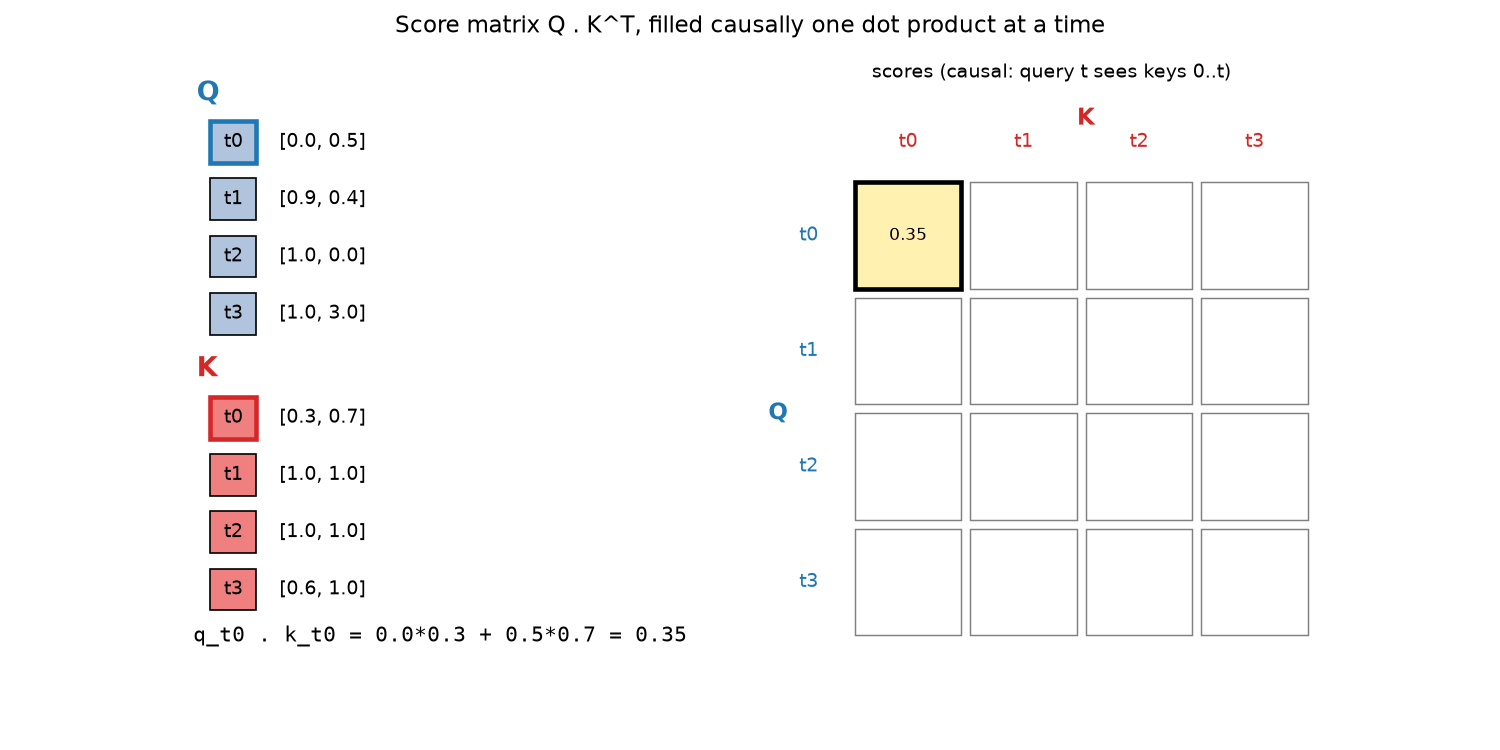

In [ ]:
"""Animated Q.K score matrix, filled causally one cell per frame.

Layout follows the common attention-explainer diagram: the Q and K
vector lists on the left, the score grid on the right. Each frame
highlights one (query, key) pair, computes their dot product for real,
and fills the corresponding cell with its value and a color mapped to
its magnitude. Cells fill in causal order: query t only attends to keys
0..t, so the grid fills as a lower triangle.

Vectors here are small 2D examples so every dot product is checkable by
hand from the numbers shown on the left.

Self-contained for Google Colab. Run the whole file in one cell; the GIF
displays inline and is saved as score_matrix_animation.gif.
"""

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.patches import Rectangle

import os

try:
    _THIS_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # __file__ is undefined when this script is exec()'d or pasted into a
    # notebook/Colab cell rather than run as a standalone file. Fall back
    # to the current working directory in that case.
    _THIS_DIR = os.getcwd()
_ASSETS_DIR = os.path.join(_THIS_DIR, "assets")
os.makedirs(_ASSETS_DIR, exist_ok=True)
OUTPUT_PATH = os.path.join(_ASSETS_DIR, "score_matrix_animation.gif")


def build_animation(
    tokens: list[str] = None,
    q_vectors: np.ndarray = None,
    k_vectors: np.ndarray = None,
    output_path: str = OUTPUT_PATH,
) -> None:
    if tokens is None:
        tokens = ["t0", "t1", "t2", "t3"]
    if q_vectors is None:
        q_vectors = np.array([[0.0, 0.5],
                              [0.9, 0.4],
                              [1.0, 0.0],
                              [1.0, 3.0]])
    if k_vectors is None:
        k_vectors = np.array([[0.3, 0.7],
                              [1.0, 1.0],
                              [1.0, 1.0],
                              [0.6, 1.0]])

    n = len(tokens)
    scores = q_vectors @ k_vectors.T  # full matrix; only causal cells shown

    # Causal fill order: (0,0), (1,0), (1,1), (2,0), ...
    fill_order = [(t, j) for t in range(n) for j in range(t + 1)]

    causal_vals = [scores[t, j] for t, j in fill_order]
    vmin, vmax = min(causal_vals), max(causal_vals)
    cmap = plt.cm.YlOrBr

    def score_color(val: float):
        span = vmax - vmin if vmax > vmin else 1.0
        return cmap(0.15 + 0.7 * (val - vmin) / span)

    fig, (ax_vec, ax_grid) = plt.subplots(
        1, 2, figsize=(10, 5), dpi=150,
        gridspec_kw={"width_ratios": [1, 1.3]},
    )
    fig.suptitle("Score matrix Q . K^T, filled causally one dot product at a time",
                 fontsize=11)

    # ---- Left panel: Q and K vector lists ----
    ax_vec.set_xlim(0, 10)
    ax_vec.set_ylim(0, 10)
    ax_vec.axis("off")

    q_label_boxes, k_label_boxes = [], []
    row_height = 1.1
    q_top = 9.8
    k_gap = 0.8  # jarak antara blok Q dan blok K

    # k_top = posisi label "K" besar, tepat di atas kotak K pertama.
    q_last_box_bottom = (q_top - 0.8 - (n - 1) * row_height) - 0.4
    k_top = q_last_box_bottom - k_gap

    for i in range(n):
        y_q = q_top - 0.8 - i * row_height
        box = Rectangle((0.5, y_q - 0.4), 1.0, 0.8,
                        facecolor="lightsteelblue", edgecolor="black", linewidth=0.8)
        ax_vec.add_patch(box)
        q_label_boxes.append(box)
        ax_vec.text(1.0, y_q, tokens[i], ha="center", va="center", fontsize=9)
        ax_vec.text(2.0, y_q, f"[{q_vectors[i, 0]:.1f}, {q_vectors[i, 1]:.1f}]",
                    ha="left", va="center", fontsize=9)

        y_k = k_top - 0.8 - i * row_height
        box = Rectangle((0.5, y_k - 0.4), 1.0, 0.8,
                        facecolor="lightcoral", edgecolor="black", linewidth=0.8)
        ax_vec.add_patch(box)
        k_label_boxes.append(box)
        ax_vec.text(1.0, y_k, tokens[i], ha="center", va="center", fontsize=9)
        ax_vec.text(2.0, y_k, f"[{k_vectors[i, 0]:.1f}, {k_vectors[i, 1]:.1f}]",
                    ha="left", va="center", fontsize=9)

    k_last_box_bottom = (k_top - 0.8 - (n - 1) * row_height) - 0.4
    calc_y = k_last_box_bottom - 0.6

    ax_vec.text(0.2, q_top, "Q", fontsize=13, color="tab:blue", fontweight="bold")
    ax_vec.text(0.2, k_top, "K", fontsize=13, color="tab:red", fontweight="bold")
    calc_text = ax_vec.text(5.5, calc_y, "", fontsize=10, ha="center",
                            family="monospace")
    ax_vec.set_ylim(min(0, calc_y - 0.5), 10)

    # ---- Right panel: score grid ----
    ax_grid.set_xlim(-0.8, n + 0.2)
    ax_grid.set_ylim(-0.8, n + 0.2)
    ax_grid.invert_yaxis()
    ax_grid.set_aspect("equal")
    ax_grid.axis("off")
    ax_grid.set_title("scores (causal: query t sees keys 0..t)", fontsize=9)

    cell_patches = {}
    cell_texts = {}
    for t in range(n):
        for j in range(n):
            rect = Rectangle((j, t), 0.92, 0.92,
                             facecolor="white", edgecolor="gray", linewidth=0.7)
            ax_grid.add_patch(rect)
            cell_patches[(t, j)] = rect
            txt = ax_grid.text(j + 0.46, t + 0.46, "", ha="center", va="center",
                               fontsize=8)
            cell_texts[(t, j)] = txt

    for i in range(n):
        ax_grid.text(i + 0.46, -0.35, tokens[i], ha="center", va="center",
                     fontsize=9, color="tab:red")
        ax_grid.text(-0.4, i + 0.46, tokens[i], ha="center", va="center",
                     fontsize=9, color="tab:blue")
    ax_grid.text(n / 2, -0.50, "K", ha="center", fontsize=11,
                 color="tab:red", fontweight="bold")
    ax_grid.text(-0.75, n / 2, "Q", va="center", fontsize=11,
                 color="tab:blue", fontweight="bold")

    def update(frame_idx: int):
        t, j = fill_order[frame_idx]

        # Reset all fills up to this frame, then re-apply.
        for (tt, jj), rect in cell_patches.items():
            k = fill_order.index((tt, jj)) if (tt, jj) in fill_order else None
            if k is not None and k <= frame_idx:
                rect.set_facecolor(score_color(scores[tt, jj]))
                cell_texts[(tt, jj)].set_text(f"{scores[tt, jj]:.2f}")
            else:
                rect.set_facecolor("white")
                cell_texts[(tt, jj)].set_text("")
            rect.set_edgecolor("gray")
            rect.set_linewidth(0.7)

        # Highlight the current cell and the vectors that produced it.
        cell_patches[(t, j)].set_edgecolor("black")
        cell_patches[(t, j)].set_linewidth(2.2)

        for i, box in enumerate(q_label_boxes):
            box.set_linewidth(2.2 if i == t else 0.8)
            box.set_edgecolor("tab:blue" if i == t else "black")
        for i, box in enumerate(k_label_boxes):
            box.set_linewidth(2.2 if i == j else 0.8)
            box.set_edgecolor("tab:red" if i == j else "black")

        qv, kv = q_vectors[t], k_vectors[j]
        calc_text.set_text(
            f"q_{tokens[t]} . k_{tokens[j]} = "
            f"{qv[0]:.1f}*{kv[0]:.1f} + {qv[1]:.1f}*{kv[1]:.1f} "
            f"= {scores[t, j]:.2f}"
        )
        return []

    anim = FuncAnimation(fig, update, frames=len(fill_order),
                         interval=900, blit=False, repeat=True)
    writer = PillowWriter(fps=1.1)
    anim.save(output_path, writer=writer)
    plt.close(fig)
    print(f"wrote {output_path}")


def main() -> None:
    build_animation()
    try:
        from IPython.display import Image as IPImage
        from IPython.display import display
        display(IPImage(OUTPUT_PATH))
    except ImportError:
        pass


if __name__ == "__main__":
    main()

In [ ]:

if __name__ == "__main__":
    main()